## Extra Project 2
### Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)

### <strong style='color:orange ; background-color:black;'> This is a continuation of `ex1_01_main`, where I'm going to try to optimize even further using Tuomas' advice!</strong>

<br>

<br>

##### Shape: `34k rows, 19 columns`

##### Target Variable: `sale_price`

##### Method: `Linear Regression`

##### Column Descriptions (Complete):

| Column        | Description |
|--------------|-------------|
| borough_x    | *Borough code associated with the property sale record, sourced from the NYC Citywide Rolling Sales dataset.* |
| block        | *NYC tax block identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| lot          | *NYC tax lot identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| sale_price   | *Recorded sale price of the property transaction in US dollars. Non-arm’s-length and invalid transactions have been removed.* |
| zip_code     | *ZIP code of the property as recorded in the sales transaction data.* |
| borough_y    | *Borough code associated with the property tax lot, sourced from the PLUTO building dataset.* |
| yearbuilt    | *Year in which the primary structure on the tax lot was originally constructed.* |
| lotarea      | *Total land area of the tax lot, measured in square feet.* |
| bldgarea     | *Total gross building floor area on the tax lot, measured in square feet.* |
| resarea      | *Portion of the building floor area used for residential purposes, measured in square feet.* |
| comarea      | *Total commercial floor area within the building, measured in square feet.* |
| unitsres     | *Number of residential housing units on the tax lot.* |
| unitstotal   | *Total number of units on the tax lot, including residential and non-residential units.* |
| numfloors    | *Number of floors in the primary building on the tax lot.* |
| latitude     | *Latitude coordinate of the property location, expressed in decimal degrees.* |
| longitude    | *Longitude coordinate of the property location, expressed in decimal degrees.* |
| landuse      | *Numeric land use category code describing the primary use of the property (e.g., residential, commercial, mixed-use).* |
| bldgclass    | *NYC building class code indicating the structural and usage classification of the property.* |
| building_age | *Age of the building in years at the time of sale, calculated as sale year minus year built.* |


<br>
<br>

<i> 

This is the main notebook for exercise project 1. The approach for this notebook was to have only <b>minimal comments and prioritize readability </b> (my initial version had way too much explanations. This is the TL:DR version).



---

### Code

##### Installing requirements
`pip install -r requirements.txt`

In [45]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from skfeature.function.similarity_based import fisher_score
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

<br>

<i>
In this section, we'll check for missing values, check for duplicates, drop some initial columns (multicollinearity) and check for isolated cases in the categorical columns.
</i>

#### Checking The Dataframe Shape

In [46]:
# Checking the amount of columns and rows.
df.shape

(34439, 19)

#### Handling Missing Values

In [47]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. Not timeseries, so it's fine.

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64

In [48]:
# Dropping nan values.
df = df.dropna()

#### Handling Duplicates

In [49]:
# Checking for duplicates
df.duplicated().value_counts()

# Some duplicates do exist. We can safely get rid of these.

False    33204
True       999
Name: count, dtype: int64

In [50]:
# Dropping the duplicate rows.
df = df.drop_duplicates()

#### Dropping Columns

<i>
In the cell below, we'll be dropping some of the columns which we know we won't be using. each column has a justification as a sidecomment. 
</i>



In [51]:
# Dropping co-dependent/high collinearity columns
df = df.drop(["borough_x",       # Related to borough_y
                'latitude',      # Probably just noise in the data. Definitely not linear.
                'longitude',     # Probably just noise in the data. Definitely not linear.
                'yearbuilt',     # This is co-dependent with `buildingage`
                'comarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'resarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'lot',           # We have borough_y. This is too specific, you'd have distributions of 1 unit being in lot ABC, hardly statistical.
                'block',         # We have borough_y, too specific. We cant have 3 units in a block be a statistical weight for an ML model.
                'zip_code',      # Too specific, it'll affect distribution.
                'landuse',       # This is often co-dependent with bldgclass (D4 bldgclass = landuse 3 for example).      
], axis=1)

# `borough_y` and `bldglclass` is categorical, we'll convert this to numbers. 
df.head(3)


,sale_price,borough_y,lotarea,bldgarea,unitsres,unitstotal,numfloors,bldgclass,building_age
0,280000,MN,2404.0,6875.0,18.0,18.0,5.0,C6,125.0
1,2000000,MN,1919.0,7810.0,8.0,10.0,5.0,C4,125.0
2,3400000,MN,2150.0,6152.0,8.0,9.0,5.0,C7,105.0


#### Categorical Feature Isolated Case Elimination

<i>
In the cells below, we'll check the categorical column's value counts. If there isn't enough cases of a certain value, we drop it. I made an image which describes why.


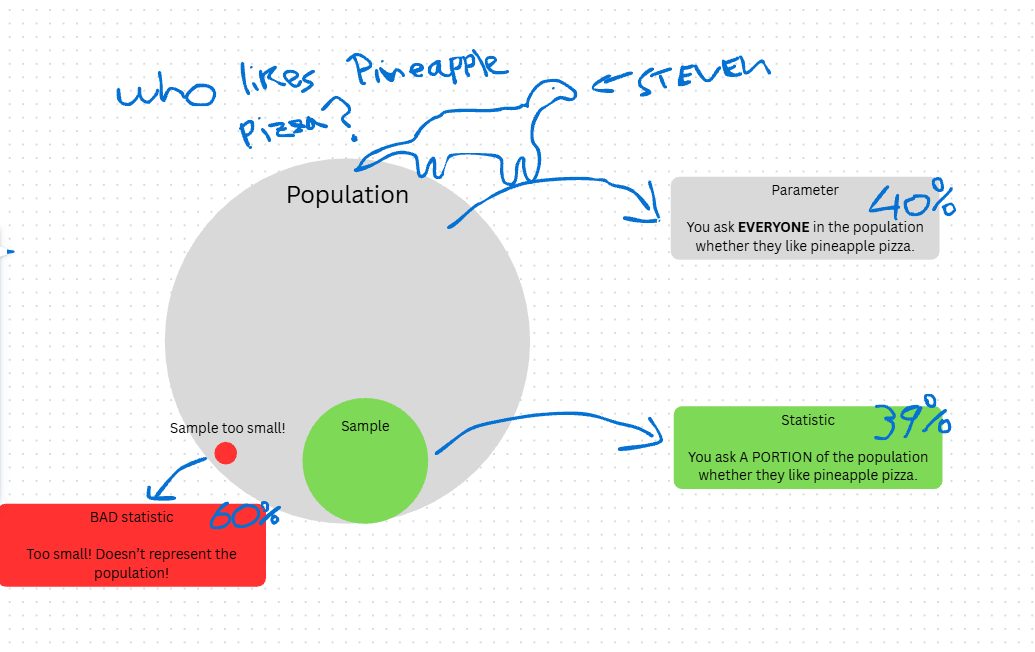

</i>

##### `bldgclass`

In [52]:
# In `bldgclass`, there are isolated cases there just isn't enough data
# to give a fair statistical weight to them.
value_counts = df['bldgclass'].value_counts().sort_values(ascending=True)
value_counts

# This eliminates any building classes that have less than 20 values. 
df = df[df['bldgclass'].isin(value_counts[value_counts >= 20].index)]

#### Categorical Feature Isolated Case Elimination

##### `borough_y`

In [53]:
# Let's check the other categorical feature, `borough_y`
df['borough_y'].value_counts()

# This seems ok! plenty of data to work with.

borough_y
QN    12619
BK     9532
SI     3842
MN     3717
BX     3221
Name: count, dtype: int64

#### Turning Categorical Columns into Numbers

<i> 
Now, we'll begin turning every possible feature into numbers.
</i>

In [54]:
# List of columns to convert to numbers.
categorical_columns = ["borough_y",  # Example values: MN, ME, BK
                       "bldgclass",  # Example values: C6, K4, C8
                       ]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

df.head(3)

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O2,bldgclass_O5,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9
0,280000,2404.0,6875.0,18.0,18.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2000000,1919.0,7810.0,8.0,10.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3400000,2150.0,6152.0,8.0,9.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


---



### Transformation

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| <bold style="background:yellow;color:black;">Transformation </bold>|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|


####  Target Variable Outlier & Skew Elimination

<i>
Here, we'll check the column `sale_price` distribution and we'll fix it (I've tried many different transformations, truncation worked best for me.)
</i>

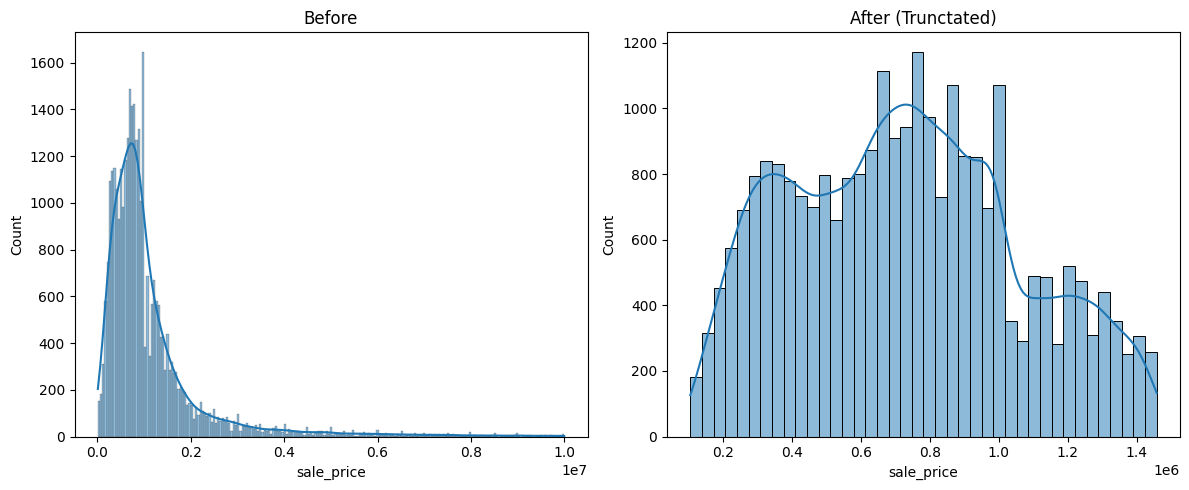

Rows left: 26016


In [55]:
from sklearn.preprocessing import PowerTransformer

# Target variable cutoffs 
y_trunc_floor = 0.01
y_trunc_ceiling = 0.80

# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histplot 0
sns.histplot(df, x='sale_price', ax=axes[0], kde=True)

# Truncating the Y variable.
df = df[
    (df["sale_price"] >= df["sale_price"].quantile(q=y_trunc_floor)) &
    (df["sale_price"] <= df["sale_price"].quantile(q=y_trunc_ceiling))
    ]

# Histplot 1
sns.histplot(df, x='sale_price', ax=axes[1], kde=True)

# Plot titles
axes[0].set_title("Before")
axes[1].set_title("After (Trunctated)")
plt.tight_layout()
plt.show()

# SANITY CHECK:
# Let's check how many rows we have left.
print(f"Rows left: {df.shape[0]}")

# Since this is eliminating information, we won't have to worry about a data leak here.

---

#### 

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|<bold style="background:yellow;color:black;">ML Training & Metrics</bold>|
|4| Tester Row Values|
|5| Personal Analysis|
|6| Advanced Tasks|


#### `LinearRegression` ML Model Training & Logging

<i>
I train the model here and dump the model to a joblib that I place in the 'models' subdirectory inside of the project.
</i>






In [57]:
from sklearn.feature_selection import RFE
import xgboost as xgb

# Constants (These are used to log the parameters in mlflow, that way I can remember what works)
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df.drop("sale_price", axis=1)
y = df['sale_price']

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)


# USING RFE with xgboost
rfe = RFE(xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42      
), n_features_to_select=40, step=10)

# These hyperparameters kind of remind me of `CatBoostRegressor`!

X_train_selected = rfe.fit_transform(X_train, y_train)
X_test_selected = rfe.transform(X_test)

# Step 2: Run a make_pipeline. Using the chaining method 
# from Tuomas' snippet. 
pipeline = make_pipeline(
    StandardScaler(),
    xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42      
))

# Initalize and fit the model.
pipeline.fit(X_train_selected, y_train)

# Predict the data with the model.
predictions = pipeline.predict(X_test_selected)

# Metrics recording (print is in the cell below)
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)

# Save the model using joblib
joblib.dump(pipeline, "models/ex1_extra2.pkl")


['models/ex1_extra2.pkl']

#### Metric & Parameter Prints


In [58]:
# -- METRICS RECORDING -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)


# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
220666.7 

MSE
79636611072.0 

RMSE
282199.59 

R-squared:
0.18 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.01, 0.8) 

X,Y Split:
0.3



#### Scatterplot Linearity Test

<i>
Awful result, but I've been on this notebook for maybe 30-40 hours. I've done a number of transformations, some feature selection, and learned quite a bit about dataleaks. Nothing. The dataset is likely just too broad.
</i>

<Axes: xlabel='sale_price'>

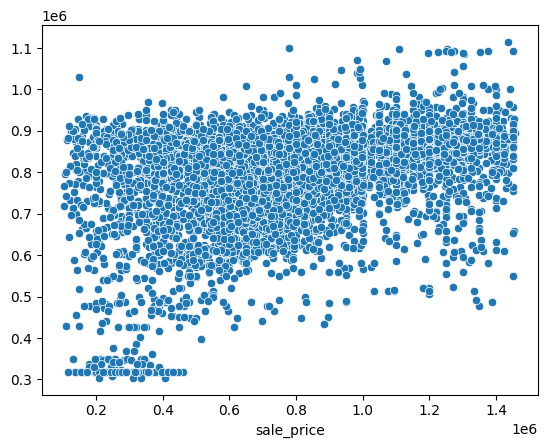

In [59]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)

---

### Tester Row Values

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| <bold style="background:yellow;color:black;">Tester Row Values</bold>|
|5| Personal Analysis |
|6| Advanced Tasks|

<br>

<i>
Here, we'll create an example prediction dictionary row. I can refer to this when I create my GUI.
</i>

In [60]:
tester_row = {
    'lotarea': 19000,
    'unitstotal': 20,
    'bldgclass_D4': 0,
    'bldgarea': 0,
    'unitsres': 25,
    'bldgclass_C6': 1,
    'numfloors': 7,
    'bldgclass_G4': 0,
    'borough_y_BX': 0,
    'borough_y_MN': 1,
    'bldgclass_A6': 0,
}

# Convert to pandas format
tester_row = pd.DataFrame([tester_row])

# Predict the result from the information above. (Note: this runs the transformations too.)
result = lm.predict(tester_row)[0]

# Print the result.
print(f"Predicted price for this home:")
print(f"$ {round(float(result), 2)}")

NameError: name 'lm' is not defined

---

### Personal Analysis

<br>

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis </bold>|
|6| Advanced Tasks|

<i> So, what went wrong? </i>

#### Creating a Dataframe with `predicted_price` and `error_margin`

<i>
This is mostly used for myself. I'm creating a dataframe that easily lets us check the results in one dataframe. It's useful to have a DataFrame with the predictions and actuals all-in-one.
</i>

In [ ]:
# Adding a column to the dataframe which predicted the price.
case_df = df
case_df['predicted_price'] = lm.predict(X).round(2)

# Creating an error margin column for the price for each row.
case_df["error_margin"] = abs(df["sale_price"] - df['predicted_price']).round(2)

case_df = case_df.sort_values("error_margin", ascending=False)

# Here, we can see some of the extreme cases with high error margins.
# NOTE: `error_margin` and `predicted_price` is at the end of the dataset
case_df

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9,predicted_price,error_margin
4039,1400000,11.835900,73.631723,1.733755,7.343420,6.0,73.0,0,0,0,...,0,0,0,0,0,0,0,0,294536.55,1105463.45
12299,1400000,10.518700,52.344118,1.685474,5.241483,6.0,109.0,1,0,0,...,0,0,0,0,0,0,0,0,390304.83,1009695.17
12302,1377500,10.518700,52.344118,1.685474,5.241483,6.0,109.0,1,0,0,...,0,0,0,0,0,0,0,0,390304.83,987195.17
23199,1350000,10.172025,42.682720,1.640079,4.272659,6.0,70.0,0,1,0,...,0,0,0,0,0,0,0,0,370797.06,979202.94
17609,1415000,9.380252,30.723168,1.541107,3.174802,4.0,123.0,1,0,0,...,0,0,0,0,0,0,0,0,438754.54,976245.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31525,825000,8.006701,12.690935,0.822112,1.259921,2.5,45.0,0,0,0,...,0,0,0,0,0,0,0,0,825030.20,30.20
29663,799000,7.601402,10.857670,0.575202,1.000000,2.0,90.0,0,0,0,...,0,0,0,0,0,0,0,0,798975.06,24.94
10068,835000,7.601402,14.422496,0.822112,1.259921,2.0,105.0,1,0,0,...,0,0,0,0,0,0,0,0,834985.70,14.30
10221,295000,12.845294,64.742969,1.724814,6.782423,3.0,75.0,0,0,0,...,0,0,0,0,0,0,0,0,294991.37,8.63


#### Creating a Scatterplot with hue as different used features

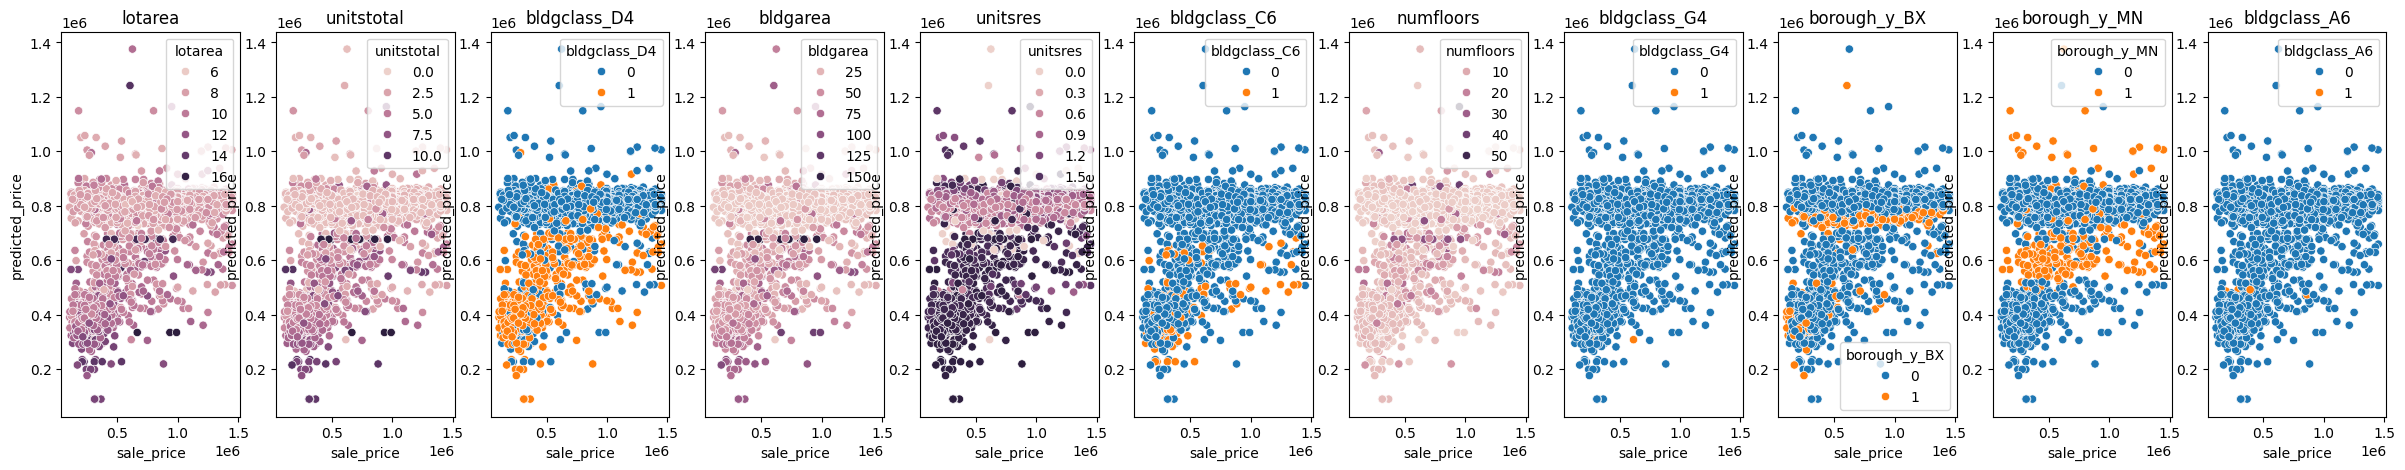

In [ ]:

# This makes a scatterplot for every predictive feature in X. 

# Take a small amount of the case dataframe. 
case_sample = case_df.sample(3000)

# The number of features in the model.
feature_amount = len(features_list)

# Create a multiplot canvas with the amount of features as the number of plot.
fig, axes = plt.subplots(1, feature_amount , figsize=(30, 5))

# turn each plot into a scatterplot for every feature in the list.
for index, feature in enumerate(features_list):
    sns.scatterplot(case_sample, x="sale_price", y="predicted_price", hue=feature, ax=axes[index])
    axes[index].set_title(feature)
    
# We're looking for patterns that could give us a clue for why fitting this model didn't work.

list(X.columns)


<i>


 We're looking for diagonal lines here. clearly, that didn't happen. Let's see if we can find some worst offenders. `bldgclass D4` and `borough_y_MN`. 

In `borough_y_MN`, we can see how the model wasn't robust enough to make a valid prediction (wide variance of sale prices, but roughly the same prediction levels).

With `bldgclass_D4`, we see a wide, scattered pattern of one color . My theory is that there's some lurking variable in this column, something the current dataset doesn't do a good job of explaining. I think it's that because `unitsres` also has that same general shape. 

TLDR: I would use a model for each of these big clusters separately

---